## NoteBook for metadata ISIC2018

After analysis we can confirm that is no metadata file for ISIC2018. 
The file we tought might be one (ISIC2018_Task3_Training_GroundTruth.csv) relates to the HAM10000.
Consequently, this notebook maybe redundant. It only provices a classification distribution between malignant and benin lesions. Other metadata analysis is provided somewhere else.

### Insuring the folders are clean and contains only the required file type
```
data/isic2018/
|--  images/        # .jpg only
|--  masks/         # .png only
|--  txt/
  |--  images/      # .txt originally from images/
  |--  masks/       # .txt originally from masks/


data/ham10000/
|--  images/        # .jpg only
|--  masks/         # .png only
|--  txt/
  |--  images/      # .txt originally from images/
  |--  masks/       # .txt originally from masks/
|--HAM10000_metadata.csv
|--ISIC2018_Task3_Training_GroundTruth.csv
```


### SKIN Lesion Diagnostic categories
The diagnostic categories and abbreviations follow the definitions provided in the HAM10000 dataset and the ISIC 2018 challenge, which are widely used benchmarks in dermatological image analysis.

| Abbreviation | Full name                                     | Description                                                         | Malignant / Benign |
| ------------ | --------------------------------------------- | ------------------------------------------------------------------- | ------------------ |
| **MEL**      | Melanoma                                      | Malignant tumor of melanocytes; most dangerous form of skin cancer. | **Malignant**      |
| **BCC**      | Basal Cell Carcinoma                          | Slow-growing skin cancer originating from basal epidermal cells.    | **Malignant**      |
| **AKIEC**    | Actinic Keratoses / Intraepithelial Carcinoma | Precancerous lesions that may progress to squamous cell carcinoma.  | Benign*            |
| **NV**       | Melanocytic Nevi                              | Common benign moles formed by clusters of melanocytes.              | Benign             |
| **BKL**      | Benign Keratosis-like Lesions                 | Includes seborrheic keratoses and similar benign proliferations.    | Benign             |
| **DF**       | Dermatofibroma                                | Benign fibrous skin nodules, often following minor skin trauma.     | Benign             |
| **VASC**     | Vascular Lesions                              | Benign vascular tumors such as angiomas or hemorrhages.             | Benign             |

* Note on AKIEC:
AKIEC lesions are clinically precancerous. In most machine learning and ISIC/HAM10000 studies, they are grouped under benign for binary classification, although they represent a higher-risk category than other benign lesions.

          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC binary_label
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0       benign
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0       benign
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0       benign
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0       benign
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0    malignant
                MEL            NV           BCC         AKIEC           BKL  \
count  10015.000000  10015.000000  10015.000000  10015.000000  10015.000000   
mean       0.111133      0.669496      0.051323      0.032651      0.109735   
std        0.314313      0.470418      0.220667      0.177730      0.312575   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      0.000000      0.000000      0.000000   
50%        0.000000      1.000000      0.000000      0.000000      0.000000   
75%        0.000000      1.000000      0.0000

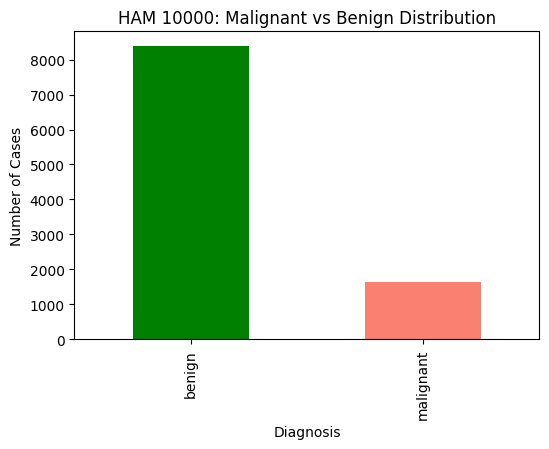

In [7]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

ROOT = Path("..") # Adjust if this notebook is not in <src>/
ISIC_DIR = ROOT / "data" / "isic2018"
ISIC_IMG_DIR  = ISIC_DIR / "images"
ISIC_MASK_DIR = ISIC_DIR / "masks"

HAM_DIR = ROOT / "data" / "ham10000"
HAM_IMG_DIR = HAM_DIR / "images"
HAM_MASK_DIR = HAM_DIR / "masks"  # Tschandl masks unzipped
HAM_META = HAM_DIR / "HAM10000_metadata.csv"
HAM_GT = HAM_DIR / "ISIC2018_Task3_Training_GroundTruth.csv" # ground truth for ISIC 2018 Task 3 - related to HAM10000

assert ISIC_IMG_DIR.exists(), f"Missing {ISIC_IMG_DIR}"
assert ISIC_MASK_DIR.exists(), f"Missing {ISIC_MASK_DIR}"


# Load metadata
ham_gt = pd.read_csv(HAM_GT)
ham_meta = pd.read_csv(HAM_META)   


# label mapping for HAM10000
malignant = ["MEL", "BCC"]
ham_gt["binary_label"] = (
    ham_gt[malignant].max(axis=1)
    .map({1: "malignant", 0: "benign"})
)
print(ham_gt.head())
print(ham_gt.describe())

# plot malignant vs benign distribution
plt.figure(figsize=(6,4))
ham_gt["binary_label"].value_counts().plot(kind="bar", color=["green", "salmon"])
plt.title("HAM 10000: Malignant vs Benign Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Cases")
plt.show() 

The ISIC 2018 segmentation dataset does not provide diagnostic labels for the images used in Task 1. Consequently, diagnostic stratification was not performed for ISIC 2018, and benign/malignant analysis was conducted exclusively using the HAM10000 dataset, which provides curated diagnostic metadata.